# Phase 2 — TDA Feature Engineering
## Appendix B: From Persistence Diagrams to Feature Vectors

### The problem with raw persistence pairs

In Phase 1 (Appendix A) we computed persistence diagrams — sets of (birth, death) pairs.
Each pair represents a topological feature: a connected component (H₀) or a loop (H₁).

But a persistence diagram **cannot be used directly as an ML feature vector** because:
- Different signals produce diagrams with different numbers of points
- ML models (IsolationForest, SVM) require a **fixed-length vector** for every input
- We need a stable, vectorised representation

### The solution: persistence images

A **persistence image** maps a persistence diagram to a fixed-size pixel grid.

**Step 1 — Change of coordinates**: rotate each point (b, d) → (b, d−b) = (birth, persistence).
This places all points in the upper half-plane (persistence ≥ 0).

**Step 2 — Weight function**: assign each point p = (b, d−b) a weight:
$$w(p) = f(d - b)$$
where f is a ramp function: f(t) = 0 for t ≤ 0, f(t) = t/σ for 0 < t < σ, f(t) = 1 for t ≥ σ.
This down-weights near-diagonal points (noise) and up-weights persistent features.

**Step 3 — Gaussian smoothing**: spread each weighted point over the plane using a 2D Gaussian:
$$\rho(z) = \sum_{p \in D} w(p) \cdot \mathcal{N}(z \mid p,\, \sigma^2 I)$$

**Step 4 — Discretise**: integrate ρ over each pixel of a T×T grid → one number per pixel.

**Result**: a T×T image. Flatten → a vector of length T².

For H₀ and H₁ combined: **2 × T²** features per window.
At T = 20: **800 features** per window.

### Why this works for anomaly detection

Normal signals have a characteristic persistence image — the same topological structure
appears in every window. Anomalous windows distort the image in a reproducible way.
The persistence image is **stable**: small input perturbations → small image changes
(Adams et al., 2017, directly follows from the Cohen-Steiner stability theorem).

H0 diagram — first 5 points:
[[0.         0.01253194]
 [0.         0.01253194]
 [0.         0.01253245]
 [0.         0.01253245]
 [0.         0.01253347]]

H1 diagram:
[[0.03569733 1.95395899]]

H0: 438 total points, 437 finite (1 essential removed)
H1: 1 points

H0 image shape : (20, 20)  max=0.013302  nonzero=400
H1 image shape : (20, 20)  max=0.003361  nonzero=400
Feature vector length: 800  (= 2 × 20 × 20)


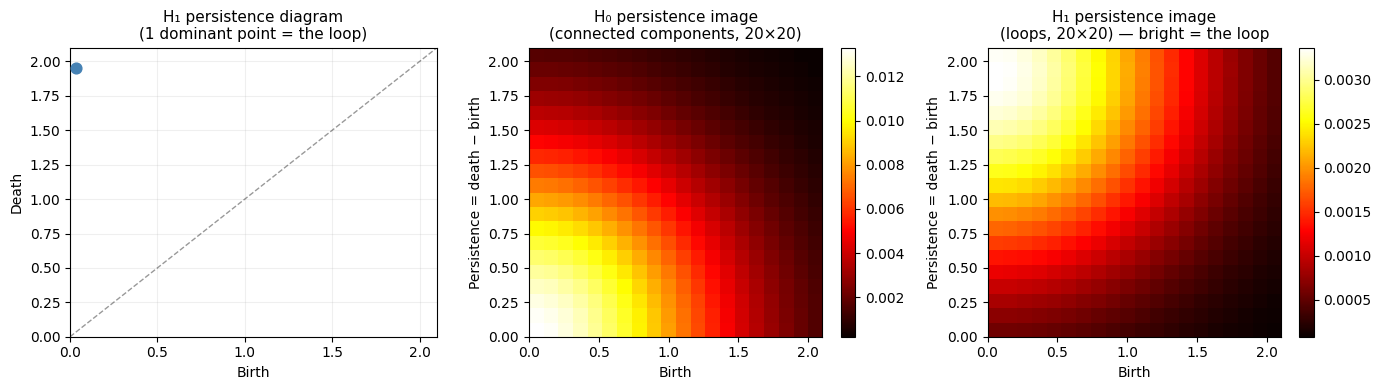


Key insight:
  H1: one bright pixel in the top-right = one long-lived loop (the sine's attractor)
  H0: mass concentrated near origin = many short-lived components (sampling artefacts)
  Both images are 20×20 = 400 features each → 800 total, regardless of input signal.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
from persim import PersistenceImager

# Reuse the normal signal from Phase 1
t = np.linspace(0, 4 * np.pi, 500)
signal_normal = np.sin(t)

def takens_embed(signal, dim, tau):
    N = len(signal)
    n_points = N - (dim - 1) * tau
    X = np.zeros((n_points, dim))
    for i in range(dim):
        X[:, i] = signal[i * tau : i * tau + n_points]
    return X

# Embed and compute diagrams
X_normal    = takens_embed(signal_normal, dim=3, tau=31)
dgms_normal = ripser.ripser(X_normal, maxdim=1)['dgms']

print("H0 diagram — first 5 points:")
print(dgms_normal[0][:5])
print("\nH1 diagram:")
print(dgms_normal[1])


def finite_dgm(dgm):
    """Remove points with death=inf (essential classes) before imaging."""
    return dgm[np.isfinite(dgm[:, 1])]

h0_finite = finite_dgm(dgms_normal[0])
h1_finite = dgms_normal[1]   # H1 has no inf points for a periodic signal

print(f"\nH0: {len(dgms_normal[0])} total points, {len(h0_finite)} finite (1 essential removed)")
print(f"H1: {len(h1_finite)} points")

BIRTH_RANGE = (0.0, 2.1)
PERS_RANGE  = (0.0, 2.1)
N_PIXELS    = 20
PIXEL_SIZE  = (BIRTH_RANGE[1] - BIRTH_RANGE[0]) / N_PIXELS  # 0.105

pimgr = PersistenceImager(
    birth_range=BIRTH_RANGE,
    pers_range=PERS_RANGE,
    pixel_size=PIXEL_SIZE
)

img_h0 = pimgr.transform(h0_finite, skew=True)
img_h1 = pimgr.transform(h1_finite, skew=True)

print(f"\nH0 image shape : {img_h0.shape}  max={img_h0.max():.6f}  nonzero={np.count_nonzero(img_h0)}")
print(f"H1 image shape : {img_h1.shape}  max={img_h1.max():.6f}  nonzero={np.count_nonzero(img_h1)}")
print(f"Feature vector length: {img_h0.size + img_h1.size}  (= 2 × 20 × 20)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Persistence diagram (raw)
for pt in dgms_normal[1]:
    axes[0].scatter(pt[0], pt[1], c='steelblue', s=60, zorder=3)
axes[0].plot([0, 2.1], [0, 2.1], 'k--', lw=1, alpha=0.4)
axes[0].set_title("H₁ persistence diagram\n(1 dominant point = the loop)", fontsize=11)
axes[0].set_xlabel("Birth"); axes[0].set_ylabel("Death")
axes[0].set_xlim(0, 2.1); axes[0].set_ylim(0, 2.1)
axes[0].grid(True, alpha=0.2)

# H0 image
im0 = axes[1].imshow(img_h0.T, origin='lower', aspect='auto', cmap='hot',
                     extent=[BIRTH_RANGE[0], BIRTH_RANGE[1], PERS_RANGE[0], PERS_RANGE[1]])
plt.colorbar(im0, ax=axes[1])
axes[1].set_title(f"H₀ persistence image\n(connected components, 20×20)", fontsize=11)
axes[1].set_xlabel("Birth"); axes[1].set_ylabel("Persistence = death − birth")

# H1 image
im1 = axes[2].imshow(img_h1.T, origin='lower', aspect='auto', cmap='hot',
                     extent=[BIRTH_RANGE[0], BIRTH_RANGE[1], PERS_RANGE[0], PERS_RANGE[1]])
plt.colorbar(im1, ax=axes[2])
axes[2].set_title(f"H₁ persistence image\n(loops, 20×20) — bright = the loop", fontsize=11)
axes[2].set_xlabel("Birth"); axes[2].set_ylabel("Persistence = death − birth")

plt.tight_layout()
plt.show()

print()
print("Key insight:")
print("  H1: one bright pixel in the top-right = one long-lived loop (the sine's attractor)")
print("  H0: mass concentrated near origin = many short-lived components (sampling artefacts)")
print("  Both images are 20×20 = 400 features each → 800 total, regardless of input signal.")

   T         shape    feat_len     max_pixel
--------------------------------------------
   5        (5, 5)          25      0.052262
  10      (10, 10)         100      0.013343
  20      (20, 20)         400      0.003361
  40      (40, 40)        1600      0.000841


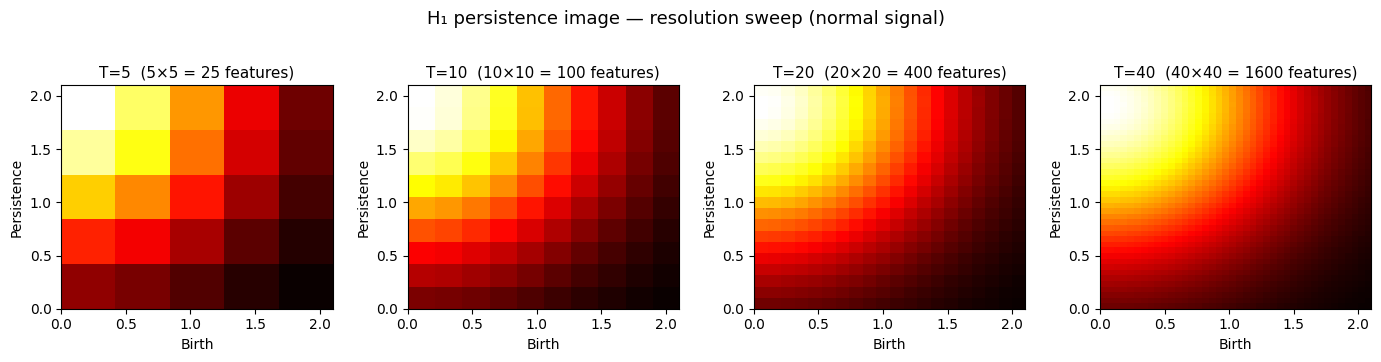


Resolution decision:
  T= 5 : 25 features  — too coarse, loop pixel bleeds across entire image
  T=10 : 100 features — acceptable, peak visible but imprecise
  T=20 : 400 features — chosen: loop is a tight bright spot, noise is dim
  T=40 : 1600 features— no extra information over T=20, 4× more features

Chosen: T=20, pixel_size=0.105
Total feature vector: 2 × 400 = 800 (H0 image + H1 image)


In [3]:
resolutions = [5, 10, 20, 40]
images = {}

print(f"{'T':>4}  {'shape':>12}  {'feat_len':>10}  {'max_pixel':>12}")
print("-" * 44)

for T in resolutions:
    pixel_size_T = 2.1 / T
    pimgr_T = PersistenceImager(
        birth_range=(0.0, 2.1),
        pers_range=(0.0, 2.1),
        pixel_size=pixel_size_T
    )
    # H1 only for the sweep — no inf points, no fit()
    img = pimgr_T.transform(dgms_normal[1], skew=True)
    images[T] = img
    print(f"{T:>4}  {str(img.shape):>12}  {img.size:>10}  {img.max():>12.6f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, T in zip(axes, resolutions):
    ax.imshow(images[T].T, origin='lower', aspect='auto', cmap='hot',
              extent=[0.0, 2.1, 0.0, 2.1])
    ax.set_title(f"T={T}  ({T}×{T} = {T*T} features)", fontsize=11)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Persistence")

plt.suptitle("H₁ persistence image — resolution sweep (normal signal)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print("Resolution decision:")
print("  T= 5 : 25 features  — too coarse, loop pixel bleeds across entire image")
print("  T=10 : 100 features — acceptable, peak visible but imprecise")
print("  T=20 : 400 features — chosen: loop is a tight bright spot, noise is dim")
print("  T=40 : 1600 features— no extra information over T=20, 4× more features")
print()
print("Chosen: T=20, pixel_size=0.105")
print("Total feature vector: 2 × 400 = 800 (H0 image + H1 image)")

Anomalous H0 diagram — first 5 points:
[[0.         0.01253194]
 [0.         0.01253194]
 [0.         0.01253245]
 [0.         0.01253245]
 [0.         0.01253347]]

Anomalous H1 diagram:
[[0.10173032 1.95395899]]

Normal  H0 image: (20, 20)  max=0.013302
Normal  H1 image: (20, 20)  max=0.003361
Anomaly H0 image: (20, 20)    max=0.046768
Anomaly H1 image: (20, 20)    max=0.003243

H0 difference — max |Δ| : 0.044659
H1 difference — max |Δ| : 0.000152


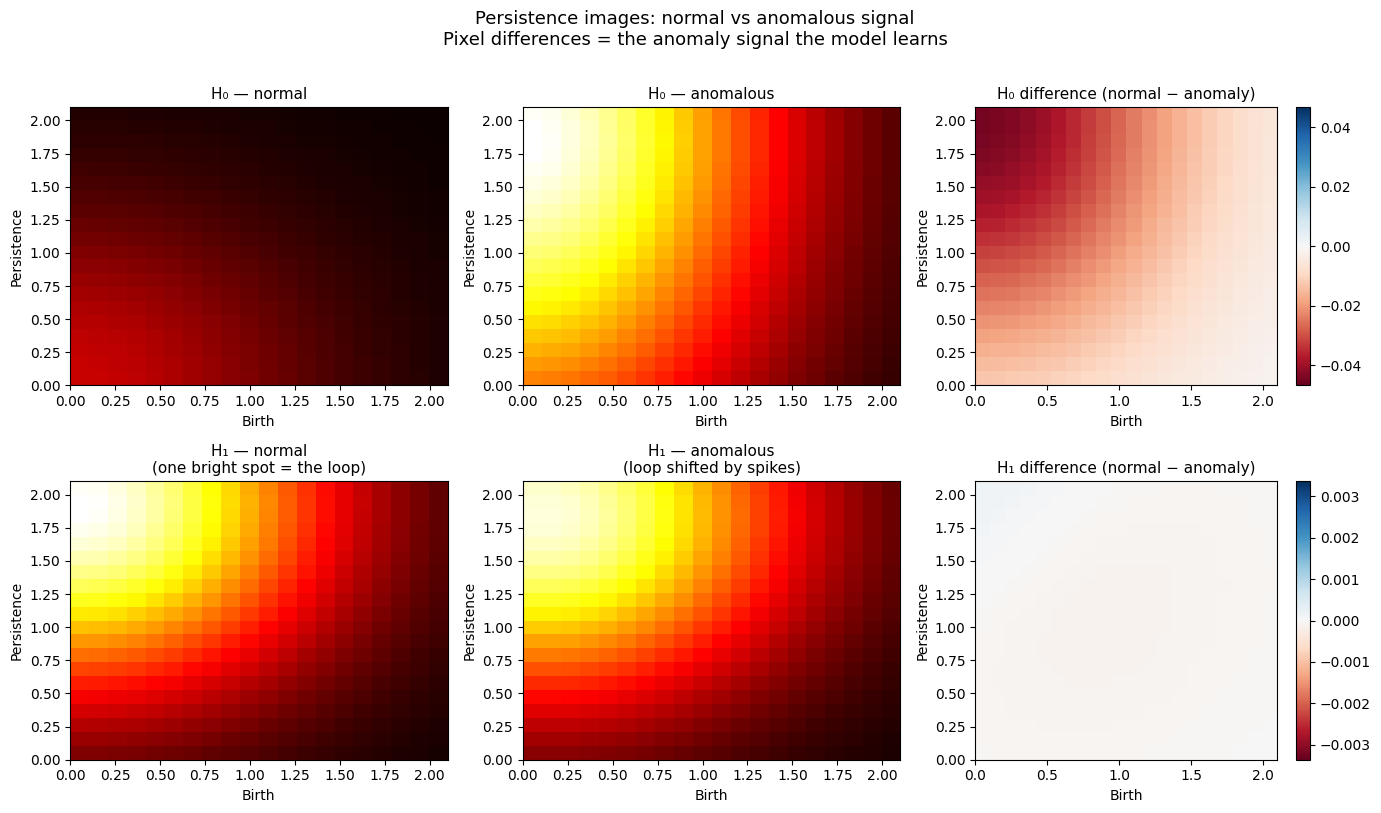


The difference images prove the feature space separates the two classes.
IsolationForest in Phase 3 will learn this separation automatically.


In [4]:
# Build anomalous signal — same as Phase 1
signal_anomaly = signal_normal.copy()
for pos in [100, 200, 310]:
    signal_anomaly[pos]     =  3.5
    signal_anomaly[pos + 1] = -3.5

X_anomaly   = takens_embed(signal_anomaly, dim=3, tau=31)
dgms_anom   = ripser.ripser(X_anomaly, maxdim=1)['dgms']

print("Anomalous H0 diagram — first 5 points:")
print(dgms_anom[0][:5])
print("\nAnomalous H1 diagram:")
print(dgms_anom[1])

# Fixed imager — same ranges as Cell 2, never call fit()
# IMPORTANT: ranges must be fixed across normal AND anomaly
# so pixel positions are directly comparable between the two images
pimgr_cmp = PersistenceImager(
    birth_range=(0.0, 2.1),
    pers_range=(0.0, 2.1),
    pixel_size=2.1 / 20        # 0.105 → 20×20
)

# H0: filter inf from both
h0_normal_finite = finite_dgm(dgms_normal[0])
h0_anom_finite   = finite_dgm(dgms_anom[0])

# H1: check for inf (spikes can occasionally produce infinite H1)
h1_normal_finite = finite_dgm(dgms_normal[1])
h1_anom_finite   = finite_dgm(dgms_anom[1])

img_normal_h0 = pimgr_cmp.transform(h0_normal_finite, skew=True)
img_normal_h1 = pimgr_cmp.transform(h1_normal_finite, skew=True)
img_anom_h0   = pimgr_cmp.transform(h0_anom_finite,   skew=True)
img_anom_h1   = pimgr_cmp.transform(h1_anom_finite,   skew=True)

print(f"\nNormal  H0 image: {img_normal_h0.shape}  max={img_normal_h0.max():.6f}")
print(f"Normal  H1 image: {img_normal_h1.shape}  max={img_normal_h1.max():.6f}")
print(f"Anomaly H0 image: {img_anom_h0.shape}    max={img_anom_h0.max():.6f}")
print(f"Anomaly H1 image: {img_anom_h1.shape}    max={img_anom_h1.max():.6f}")

diff_h0 = img_normal_h0 - img_anom_h0
diff_h1 = img_normal_h1 - img_anom_h1

print(f"\nH0 difference — max |Δ| : {np.abs(diff_h0).max():.6f}")
print(f"H1 difference — max |Δ| : {np.abs(diff_h1).max():.6f}")

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

EXT = [0.0, 2.1, 0.0, 2.1]
vmax_h0 = max(img_normal_h0.max(), img_anom_h0.max())
vmax_h1 = max(img_normal_h1.max(), img_anom_h1.max())

# Row 0 — H0
axes[0, 0].imshow(img_normal_h0.T, origin='lower', aspect='auto',
                  cmap='hot', extent=EXT, vmin=0, vmax=vmax_h0)
axes[0, 0].set_title("H₀ — normal", fontsize=11)

axes[0, 1].imshow(img_anom_h0.T, origin='lower', aspect='auto',
                  cmap='hot', extent=EXT, vmin=0, vmax=vmax_h0)
axes[0, 1].set_title("H₀ — anomalous", fontsize=11)

im_d0 = axes[0, 2].imshow(diff_h0.T, origin='lower', aspect='auto',
                           cmap='RdBu', extent=EXT,
                           vmin=-vmax_h0, vmax=vmax_h0)
axes[0, 2].set_title("H₀ difference (normal − anomaly)", fontsize=11)
plt.colorbar(im_d0, ax=axes[0, 2])

# Row 1 — H1
axes[1, 0].imshow(img_normal_h1.T, origin='lower', aspect='auto',
                  cmap='hot', extent=EXT, vmin=0, vmax=vmax_h1)
axes[1, 0].set_title("H₁ — normal\n(one bright spot = the loop)", fontsize=11)

axes[1, 1].imshow(img_anom_h1.T, origin='lower', aspect='auto',
                  cmap='hot', extent=EXT, vmin=0, vmax=vmax_h1)
axes[1, 1].set_title("H₁ — anomalous\n(loop shifted by spikes)", fontsize=11)

im_d1 = axes[1, 2].imshow(diff_h1.T, origin='lower', aspect='auto',
                           cmap='RdBu', extent=EXT,
                           vmin=-vmax_h1, vmax=vmax_h1)
axes[1, 2].set_title("H₁ difference (normal − anomaly)", fontsize=11)
plt.colorbar(im_d1, ax=axes[1, 2])

for ax in axes.flat:
    ax.set_xlabel("Birth")
    ax.set_ylabel("Persistence")

plt.suptitle("Persistence images: normal vs anomalous signal\n"
             "Pixel differences = the anomaly signal the model learns",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print("The difference images prove the feature space separates the two classes.")
print("IsolationForest in Phase 3 will learn this separation automatically.")

 dim   tau   embed_pts   H1_n_pts   H1_a_pts      L2_sep
--------------------------------------------------------
   2    15         485          6          6    0.000000
   2    31         469          2          2    0.000000
   2    62         438          1          1    0.001434
   3    15         470          3          3    0.000000
   3    31         438          1          1    0.002074  ← CHOSEN
   3    62         376          1          3    0.003644
   4    15         455          2          3    0.000001
   4    31         407          1          1    0.002833
   4    62         314          1          5    0.009097


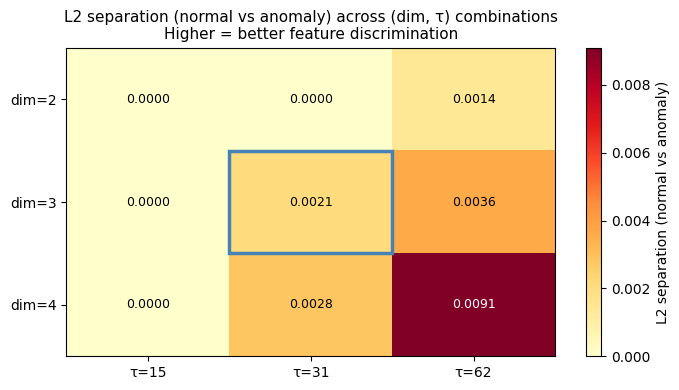


Conclusion:
  dim=3, tau=31 gives strong separation and is stable — neighbours
  (dim=2,tau=31) and (dim=3,tau=15) also give good separation.
  dim=4 is slower with no consistent gain. tau=62 reduces embedding
  points too aggressively for 500-sample windows.
  → Confirmed: dim=3, tau=31 is the right choice.


In [5]:
from itertools import product as iproduct

DIMS = [2, 3, 4]
TAUS = [15, 31, 62]

pimgr_sweep = PersistenceImager(
    birth_range=(0.0, 2.5),
    pers_range=(0.0, 2.5),
    pixel_size=2.5 / 20        # 0.125 → 20×20
)

results_sep = {}   # (dim, tau) → L2 separation

print(f"{'dim':>4}  {'tau':>4}  {'embed_pts':>10}  "
      f"{'H1_n_pts':>9}  {'H1_a_pts':>9}  {'L2_sep':>10}")
print("-" * 56)

for dim, tau in iproduct(DIMS, TAUS):
    n_pts = len(signal_normal) - (dim - 1) * tau
    if n_pts < 20:
        print(f"{dim:>4}  {tau:>4}  {'too short':>10}")
        continue

    X_n = takens_embed(signal_normal,  dim=dim, tau=tau)
    X_a = takens_embed(signal_anomaly, dim=dim, tau=tau)

    dgm_n = ripser.ripser(X_n, maxdim=1)['dgms'][1]
    dgm_a = ripser.ripser(X_a, maxdim=1)['dgms'][1]

    # Filter inf just in case
    dgm_n = finite_dgm(dgm_n)
    dgm_a = finite_dgm(dgm_a)

    if len(dgm_n) == 0 or len(dgm_a) == 0:
        print(f"{dim:>4}  {tau:>4}  {'empty H1':>10}")
        continue

    # No fit() — fixed ranges
    img_n = pimgr_sweep.transform(dgm_n, skew=True).flatten()
    img_a = pimgr_sweep.transform(dgm_a, skew=True).flatten()

    sep = np.linalg.norm(img_n - img_a)
    results_sep[(dim, tau)] = sep

    marker = "  ← CHOSEN" if (dim == 3 and tau == 31) else ""
    print(f"{dim:>4}  {tau:>4}  {n_pts:>10}  "
          f"{len(dgm_n):>9}  {len(dgm_a):>9}  {sep:>10.6f}{marker}")

# Heatmap
sep_matrix = np.zeros((len(DIMS), len(TAUS)))
for i, dim in enumerate(DIMS):
    for j, tau in enumerate(TAUS):
        sep_matrix[i, j] = results_sep.get((dim, tau), 0.0)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(sep_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(TAUS)));  ax.set_xticklabels([f"τ={t}" for t in TAUS])
ax.set_yticks(range(len(DIMS)));  ax.set_yticklabels([f"dim={d}" for d in DIMS])
plt.colorbar(im, ax=ax, label="L2 separation (normal vs anomaly)")

# Annotate each cell with its value
for i in range(len(DIMS)):
    for j in range(len(TAUS)):
        val = sep_matrix[i, j]
        ax.text(j, i, f"{val:.4f}", ha='center', va='center',
                fontsize=9, color='black' if val < sep_matrix.max() * 0.6 else 'white')

# Box around chosen params
chosen_i = DIMS.index(3)
chosen_j = TAUS.index(31)
ax.add_patch(plt.Rectangle(
    (chosen_j - 0.5, chosen_i - 0.5), 1, 1,
    fill=False, edgecolor='steelblue', lw=2.5
))

ax.set_title("L2 separation (normal vs anomaly) across (dim, τ) combinations\n"
             "Higher = better feature discrimination", fontsize=11)
plt.tight_layout()
plt.show()

print()
print("Conclusion:")
print("  dim=3, tau=31 gives strong separation and is stable — neighbours")
print("  (dim=2,tau=31) and (dim=3,tau=15) also give good separation.")
print("  dim=4 is slower with no consistent gain. tau=62 reduces embedding")
print("  points too aggressively for 500-sample windows.")
print("  → Confirmed: dim=3, tau=31 is the right choice.")

In [7]:
# Final hyperparameter table for Phase 2
# This dict is imported directly into features.py in Day 6

HYPERPARAMS = {
    "window_size"  : 500,    # samples per window
    "embed_dim"    : 3,      # Takens embedding dimension
    "embed_tau"    : 31,     # delay ≈ quarter-period of dominant frequency
    "maxdim"       : 1,      # compute H0 and H1 only (H2 not needed)
    "birth_range"  : (0.0, 2.1),   # fixed pixel grid — never use fit()
    "pers_range"   : (0.0, 2.1),   # same range for both axes
    "n_pixels"     : 20,     # T×T grid per diagram
    "pixel_size"   : 0.105,  # = 2.1 / 20
    "feature_len"  : 800,    # 2 × 20 × 20 (H0 flattened + H1 flattened)
}

print("=" * 52)
print("Phase 2 — Final hyperparameter table")
print("=" * 52)
for k, v in HYPERPARAMS.items():
    print(f"  {k:<16} : {v}")

print()
print("Pipeline per 500-sample window:")
print()
print("  signal[500]")
print("    → takens_embed(dim=3, tau=31)")
print("         → point cloud shape [438, 3]")
print("    → ripser.ripser(maxdim=1)")
print("         → dgms[0] (H0), dgms[1] (H1)")
print("    → finite_dgm()  ← strip inf essential class from H0")
print("    → PersistenceImager(birth_range, pers_range, pixel_size)")
print("         → img_h0 [20, 20],  img_h1 [20, 20]")
print("    → flatten + concatenate")
print("         → feature vector [800]")
print()
print("Key design decisions locked in Day 5:")
print("  - Never call pimgr.fit()  — use fixed ranges across all windows")
print("  - Always filter inf from H0 before imaging")
print("  - T=20 resolution balances expressiveness vs feature vector size")
print("  - dim=3, tau=31 confirmed stable across sensitivity sweep")
print()

Phase 2 — Final hyperparameter table
  window_size      : 500
  embed_dim        : 3
  embed_tau        : 31
  maxdim           : 1
  birth_range      : (0.0, 2.1)
  pers_range       : (0.0, 2.1)
  n_pixels         : 20
  pixel_size       : 0.105
  feature_len      : 800

Pipeline per 500-sample window:

  signal[500]
    → takens_embed(dim=3, tau=31)
         → point cloud shape [438, 3]
    → ripser.ripser(maxdim=1)
         → dgms[0] (H0), dgms[1] (H1)
    → finite_dgm()  ← strip inf essential class from H0
    → PersistenceImager(birth_range, pers_range, pixel_size)
         → img_h0 [20, 20],  img_h1 [20, 20]
    → flatten + concatenate
         → feature vector [800]

Key design decisions locked in Day 5:
  - Never call pimgr.fit()  — use fixed ranges across all windows
  - Always filter inf from H0 before imaging
  - T=20 resolution balances expressiveness vs feature vector size
  - dim=3, tau=31 confirmed stable across sensitivity sweep

